# 01. Data Audit

Exploratory notebook for inspecting raw holdings and price data before running the pipeline.


In [ ]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from src.ingestion.load_holdings import load_holdings
from src.ingestion.fetch_prices import fetch_prices
from src.validation.data_checks import validate_holdings, validate_prices


In [ ]:
holdings = load_holdings()
print(holdings.dtypes)
holdings

date           datetime64[ns]
ticker                 object
quantity                int64
avg_cost              float64
asset_class            object
sector                 object
region                 object
dtype: object


,date,ticker,quantity,avg_cost,asset_class,sector,region
0,2024-01-02,AAPL,50,185.2,Equity,Technology,US
1,2024-01-02,AGG,25,95.8,ETF,Fixed Income,US
2,2024-01-02,GLD,15,185.0,ETF,Commodities,Global
3,2024-01-02,IEFA,30,72.5,ETF,International,Developed
4,2024-01-02,JNJ,40,151.1,Equity,Healthcare,US
5,2024-01-02,MSFT,35,372.4,Equity,Technology,US
6,2024-01-02,SPY,20,470.0,ETF,Index,US
7,2024-01-02,XOM,30,100.5,Equity,Energy,US


In [ ]:
result = validate_holdings(holdings)
print(result.summary())

Validation: PASSED


In [ ]:
from src.ingestion.load_holdings import get_tickers
tickers = get_tickers(holdings)
prices = fetch_prices(tickers, start_date='2024-01-01')
prices.head(10)

,date,open,high,low,close,adj_close,volume,dividends,stock_splits,ticker
0,2024-01-02,187.149994,188.440002,183.889999,185.639999,183.731293,82488700,0.0,0.0,AAPL
1,2024-01-02,98.839996,98.970001,98.730003,98.779999,90.957611,9754400,0.0,0.0,AGG
2,2024-01-02,191.440002,191.889999,190.500000,190.720001,190.720001,6025600,0.0,0.0,GLD
3,2024-01-02,69.639999,69.910004,69.480003,69.580002,64.874084,9527200,0.0,0.0,IEFA
4,2024-01-02,156.929993,161.639999,156.789993,159.970001,149.659790,9622100,0.0,0.0,JNJ
5,2024-01-02,373.859985,375.899994,366.769989,370.869995,364.589417,25258600,0.0,0.0,MSFT
6,2024-01-02,472.160004,473.670013,470.489990,472.649994,461.247437,123623700,0.0,0.0,SPY
7,2024-01-02,100.919998,103.099998,100.849998,102.360001,94.847130,23483000,0.0,0.0,XOM
8,2024-01-03,184.220001,185.880005,183.429993,184.250000,182.355606,58414500,0.0,0.0,AAPL
9,2024-01-03,98.449997,98.940002,98.309998,98.830002,91.003639,10002100,0.0,0.0,AGG


In [ ]:
# Price coverage check
coverage = prices.groupby('ticker')['date'].agg(['min','max','count'])
coverage.columns = ['first_date','last_date','n_rows']
coverage

,first_date,last_date,n_rows
ticker,,,
AAPL,2024-01-02,2026-03-16,552
AGG,2024-01-02,2026-03-16,552
GLD,2024-01-02,2026-03-16,552
IEFA,2024-01-02,2026-03-16,552
JNJ,2024-01-02,2026-03-16,552
MSFT,2024-01-02,2026-03-16,552
SPY,2024-01-02,2026-03-16,552
XOM,2024-01-02,2026-03-16,552


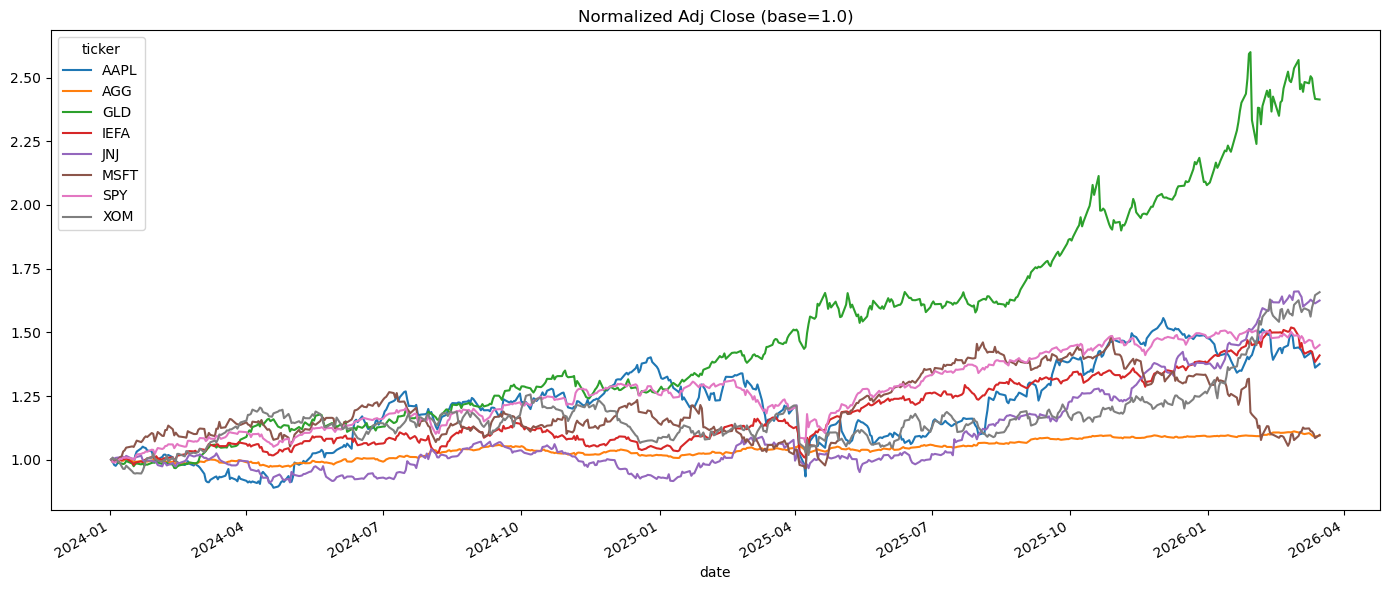

In [ ]:
# Plot raw adj_close for all tickers
panel = prices.pivot(index='date', columns='ticker', values='adj_close')
normalized = panel / panel.iloc[0]
normalized.plot(figsize=(14, 6), title='Normalized Adj Close (base=1.0)')
plt.tight_layout()
plt.show()